In [1]:
# Cell 1 — load RFM enriched data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import shap
import os

df = pd.read_csv("../data/master_df_rfm.csv")
print("Data loaded:", df.shape)
print("Churn distribution:\n", df["churned"].value_counts())

Data loaded: (113422, 31)
Churn distribution:
 churned
1    80157
0    33265
Name: count, dtype: int64


In [2]:
# Cell 2 — select and prepare features for ML
# Drop duplicates at customer level — one row per customer
customer_df = df.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (pd.to_datetime(x).max())),
    frequency=("order_id", "nunique"),
    monetary=("total_payment", "sum"),
    avg_order_value=("total_payment", "mean"),
    avg_review_score=("review_score", "mean"),
    avg_installments=("payment_installments", "mean"),
    payment_type=("payment_type", "first"),
    top_category=("product_category_name_english", "first"),
    R_score=("R_score", "first"),
    F_score=("F_score", "first"),
    M_score=("M_score", "first"),
    RFM_score=("RFM_score", "first"),
    CLV=("CLV", "first"),
    churned=("churned", "first")
).reset_index()

print("Customer level dataframe shape:", customer_df.shape)
print("\nChurn distribution:")
print(customer_df["churned"].value_counts())

Customer level dataframe shape: (96095, 15)

Churn distribution:
churned
1    68114
0    27981
Name: count, dtype: int64


In [3]:
# Cell 3 — encode categorical columns
le_payment = LabelEncoder()
le_category = LabelEncoder()

customer_df["payment_type_encoded"] = le_payment.fit_transform(
    customer_df["payment_type"].fillna("unknown"))
customer_df["top_category_encoded"] = le_category.fit_transform(
    customer_df["top_category"].fillna("unknown"))

# Final feature list
features = [
    "frequency", "monetary", "avg_order_value",
    "avg_review_score", "avg_installments",
    "R_score", "F_score", "M_score", "RFM_score", "CLV",
    "payment_type_encoded", "top_category_encoded"
]

X = customer_df[features]
y = customer_df["churned"]

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())
print("\nFeature columns:", features)

Features shape: (96095, 12)
Target distribution:
 churned
1    68114
0    27981
Name: count, dtype: int64

Feature columns: ['frequency', 'monetary', 'avg_order_value', 'avg_review_score', 'avg_installments', 'R_score', 'F_score', 'M_score', 'RFM_score', 'CLV', 'payment_type_encoded', 'top_category_encoded']


In [4]:
# Cell 4 — split data and apply SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Before SMOTE:")
print("Train set:", X_train.shape, "| Churn distribution:", y_train.value_counts().to_dict())

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Train set:", X_train_resampled.shape, 
      "| Churn distribution:", pd.Series(y_train_resampled).value_counts().to_dict())

Before SMOTE:
Train set: (76876, 12) | Churn distribution: {1: 54491, 0: 22385}

After SMOTE:
Train set: (108982, 12) | Churn distribution: {1: 54491, 0: 54491}


In [5]:
# Cell 5 — train Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_resampled, y_train_resampled)
print("Model trained ✓")

# Cross validation score
cv_scores = cross_val_score(rf_model, X_train_resampled, y_train_resampled, 
                             cv=5, scoring="roc_auc")
print(f"\nCross validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Model trained ✓

Cross validation ROC-AUC: 0.9860 (+/- 0.0055)


=== MODEL EVALUATION ===

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.99      0.85      5596
           1       1.00      0.86      0.92     13623

    accuracy                           0.89     19219
   macro avg       0.87      0.92      0.88     19219
weighted avg       0.92      0.89      0.90     19219

ROC-AUC Score: 0.9786


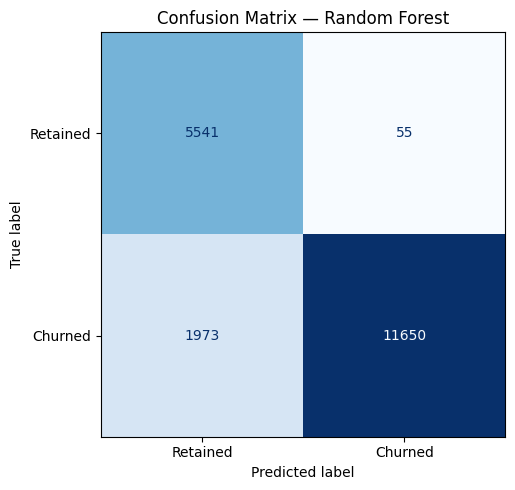

Chart 8 saved ✓


In [6]:
# Cell 6 — evaluate on test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== MODEL EVALUATION ===\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig("../outputs/chart8_confusion_matrix.png", dpi=150)
plt.show()
print("Chart 8 saved ✓")

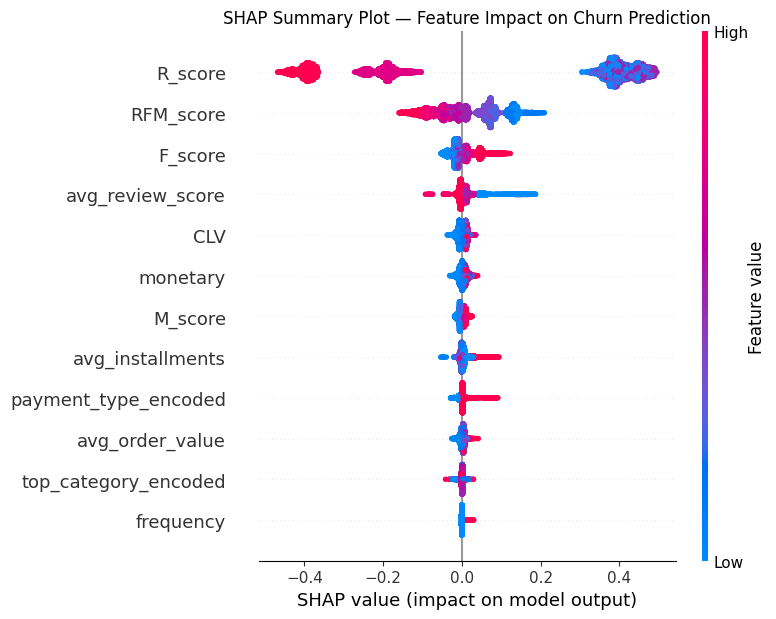

Chart 9 saved ✓


In [7]:
# Cell 7 — SHAP global feature importance (summary plot)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1] if len(shap_values.shape) == 3 
                  else shap_values[1], 
                  X_test, 
                  feature_names=features,
                  show=False)
plt.title("SHAP Summary Plot — Feature Impact on Churn Prediction")
plt.tight_layout()
plt.savefig("../outputs/chart9_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 9 saved ✓")

<Figure size 1000x600 with 0 Axes>

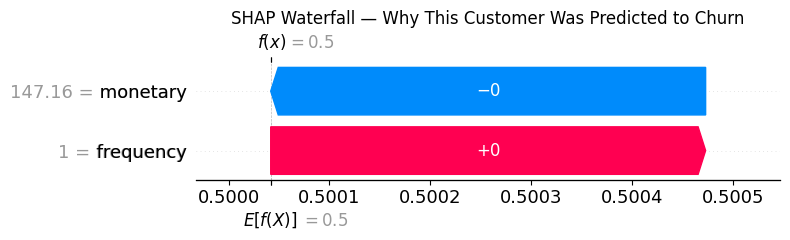

Chart 10 saved ✓


In [10]:
# Cell 8 — SHAP waterfall plot (explain one specific customer prediction)
explainer2 = shap.TreeExplainer(rf_model)
shap_values2 = explainer2.shap_values(X_test)

# Pick a churned customer to explain
churned_idx = y_test[y_test == 1].index[0]
pos = y_test.index.get_loc(churned_idx)

# Build explanation object manually for class 1 (churned)
explanation = shap.Explanation(
    values=shap_values2[1][pos],
    base_values=explainer2.expected_value[1],
    data=X_test.iloc[pos].values,
    feature_names=features
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, show=False)
plt.title("SHAP Waterfall — Why This Customer Was Predicted to Churn")
plt.tight_layout()
plt.savefig("../outputs/chart10_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 10 saved ✓")

In [11]:
# Cell 9 — save predictions back to customer dataframe
customer_df["churn_probability"] = rf_model.predict_proba(X)[:, 1]
customer_df["churn_predicted"] = rf_model.predict(X)

customer_df.to_csv("../data/customer_predictions.csv", index=False)
print("Predictions saved ✓")

print("\nAll output files:")
for f in sorted(os.listdir("../outputs")):
    print(" ✓", f)

Predictions saved ✓

All output files:
 ✓ chart10_shap_waterfall.png
 ✓ chart1_churn_by_category.png
 ✓ chart2_order_frequency.png
 ✓ chart3_revenue_churn.png
 ✓ chart4_review_vs_churn.png
 ✓ chart5_payment_vs_churn.png
 ✓ chart6_rfm_segments.png
 ✓ chart7_clv_by_segment.png
 ✓ chart8_confusion_matrix.png
 ✓ chart9_shap_summary.png


In [12]:
import os
files = sorted(os.listdir("../outputs"))
print(f"Total output files: {len(files)}")
for f in files:
    print(" ✓", f)

Total output files: 10
 ✓ chart10_shap_waterfall.png
 ✓ chart1_churn_by_category.png
 ✓ chart2_order_frequency.png
 ✓ chart3_revenue_churn.png
 ✓ chart4_review_vs_churn.png
 ✓ chart5_payment_vs_churn.png
 ✓ chart6_rfm_segments.png
 ✓ chart7_clv_by_segment.png
 ✓ chart8_confusion_matrix.png
 ✓ chart9_shap_summary.png


In [13]:
import pandas as pd
import os

# Load all key files
df_clean = pd.read_csv("../data/master_df_clean.csv")
df_rfm = pd.read_csv("../data/rfm_table.csv")
df_predictions = pd.read_csv("../data/customer_predictions.csv")

# Create a power_bi folder inside data
os.makedirs("../data/power_bi", exist_ok=True)

# Export 3 clean tables for Power BI
df_clean.to_csv("../data/power_bi/orders_master.csv", index=False)
df_rfm.to_csv("../data/power_bi/rfm_segments.csv", index=False)
df_predictions.to_csv("../data/power_bi/customer_predictions.csv", index=False)

print("Files exported for Power BI ✓")
print("\norders_master shape:", df_clean.shape)
print("rfm_segments shape:", df_rfm.shape)
print("customer_predictions shape:", df_predictions.shape)

Files exported for Power BI ✓

orders_master shape: (113422, 25)
rfm_segments shape: (96095, 12)
customer_predictions shape: (96095, 19)
